In [1]:
import os 
import glob
import zipfile
import cv2
import requests
import numpy as np
import matplotlib.pyplot as plt
from torchinfo import summary

import torch
import torchvision
import torchvision.transforms as TF

# 1. Download test images

In [2]:
# download and unzip the processed data
def download_unzip(url, save_path):
    print("Downloading and extracting assets..", end = "")
    file = requests.get(url)
    with open(save_path, "wb") as f:
        f.write(file.content)

    try:
        with zipfile.ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0])
            print("Done")

    except:
        print("Invalid file")

In [3]:
url = r"https://www.dropbox.com/s/vjpvyan2ahp1mmr/segmentation_inference_data.zip?dl=1"
dataset_name = "segmentation_inference_data"
dataset_zip_path = os.path.join(os.getcwd(), f"{dataset_name}.zip")
dataset_path = os.path.join(os.getcwd(),dataset_name)

# Download if dataset doesn't exist
if not os.path.exists(dataset_path):
    download_unzip(url, dataset_zip_path)

# 2.select segmentation model

In [4]:
def get_model(model_name, pretrained = True):

    # Initialize the model with pretrained weights if pretrained is True, else initialize with random weights
    weights = "DEFAULT" if pretrained else None
    model  = getattr(torchvision.models.segmentation, model_name)(weights = weights)

    # set the model to evaluation mode
    model.eval()
    
    return model

In [5]:
model_name = "deeplabv3_resnet50"
model = get_model(model_name)
summary(model, input_size = (1,3,256,256))

Layer (type:depth-idx)                             Output Shape              Param #
DeepLabV3                                          [1, 21, 256, 256]         --
├─IntermediateLayerGetter: 1-1                     [1, 2048, 32, 32]         --
│    └─Conv2d: 2-1                                 [1, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                            [1, 64, 128, 128]         128
│    └─ReLU: 2-3                                   [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                              [1, 64, 64, 64]           --
│    └─Sequential: 2-5                             [1, 256, 64, 64]          --
│    │    └─Bottleneck: 3-1                        [1, 256, 64, 64]          75,008
│    │    └─Bottleneck: 3-2                        [1, 256, 64, 64]          70,400
│    │    └─Bottleneck: 3-3                        [1, 256, 64, 64]          70,400
│    └─Sequential: 2-6                             [1, 512, 32, 32]          --
│    │    └─Bottlen

# Define a prediction function

In [6]:
def predict(image, model, device):
    image = image.unsqueeze(0) # add batch dimension
    image = image.to(device) # load image to device

    model = model.to(device) # load model to device

    with torch.no_grad():
        outputs = model(image) # gradients aren't needed for inference, so we use torch.no_grad() to save memory and computations

    return outputs["out"].cpu() # move output to cpu and return

# 4.Define class color mapping

In [7]:
# Pascal VOC daset color mapping.
label_color_map = [
    (0, 0, 0),       # background
    (128, 0, 0),     # aeroplane
    (0, 128, 0),     # bicycle
    (128, 128, 0),   # bird
    (0, 0, 128),     # boat
    (128, 0, 128),   # bottle
    (0, 128, 128),   # bus
    (128, 128, 128), # car
    (64, 0, 0),      # cat
    (192, 0, 0),     # chair
    (64, 128, 0),    # cow
    (192, 128, 0),   # dining table
    (64, 0, 128),    # dog
    (192, 0, 128),   # horse
    (64, 128, 128),  # motorbike
    (192, 128, 128), # person
    (0, 64, 0),      # potted plant
    (128, 64, 0),    # sheep
    (0, 192, 0),     # sofa
    (128, 192, 0),   # train
    (0, 64, 128),    # tv/monitor
]

# 5. visualization helper functions

In [8]:
def draw_segmentation_map(outputs, label_map):
    labels = torch.argmax(outputs.squeeze(), dim = 0).numpy()

    # create 3 numpy arrays containing zeros
    # later each pixel will be filled with respective red, green and vlue pixels
    # depending on predicted class

    red_map = np.zeros_like(labels).astype(np.uint8)
    green_map = np.zeros_like(labels).astype(np.uint8)
    blue_map = np.zeros_like(labels).astype(np.uint8)

    for label_num in range(0, len(label_map)):
        index = labels == label_num
        R,G,B = label_map[label_num]

        red_map[index] = R
        green_map[index] = G
        blue_map[index] = B

    segmentation_map = np.stack([red_map, green_map, blue_map], axis = 2)
    return segmentation_map

In [9]:
def image_overlay(image, segmented_image):
    alpha = 1.0 # transparency factor for original image
    beta = 0.7 # transparency factor for segmented map
    gamma = 0.0 # scalar added to each sum

    segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    image = cv2.addWeighted(image, alpha, segmented_image, beta, gamma)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image

In [10]:
def visualize(result_dir):
    plt.figure(figsize = (14,14))
    image_names = glob.glob(os.path.join(result_dir, "*.jpg"))
    for i, image_name in enumerate(image_names):
        image = plt.imread(image_name)
        plt.subplot(2,2,i+1)
        plt.imshow(image)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# 6. inference

In [11]:
# define torchvision image transforms
def get_transforms():
    return TF.Compose(
        [
            TF.ToPILImage(),
            TF.ToTensor(),
            TF.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
        ]
    )

In [12]:
transforms = get_transforms()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [13]:
OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok = True)

In [14]:
for image_name in os.listdir(dataset_path):
    # read and proess the image
    image  = cv2.imread(os.path.join(dataset_path, image_name))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_transformed = transforms(image)

    # generate predictions
    outputs = predict(image_transformed, model, device)

    # convert outputs to RGB image
    segmentation_map = draw_segmentation_map(outputs, label_color_map)

    # create overlay of original image and segmented map
    overlayed_image = image_overlay(image, segmentation_map)

    # convert overlayed image to BGR format and save to disk
    cv2.imwrite(os.path.join(OUT_DIR, image_name), overlayed_image[:,:,::-1])

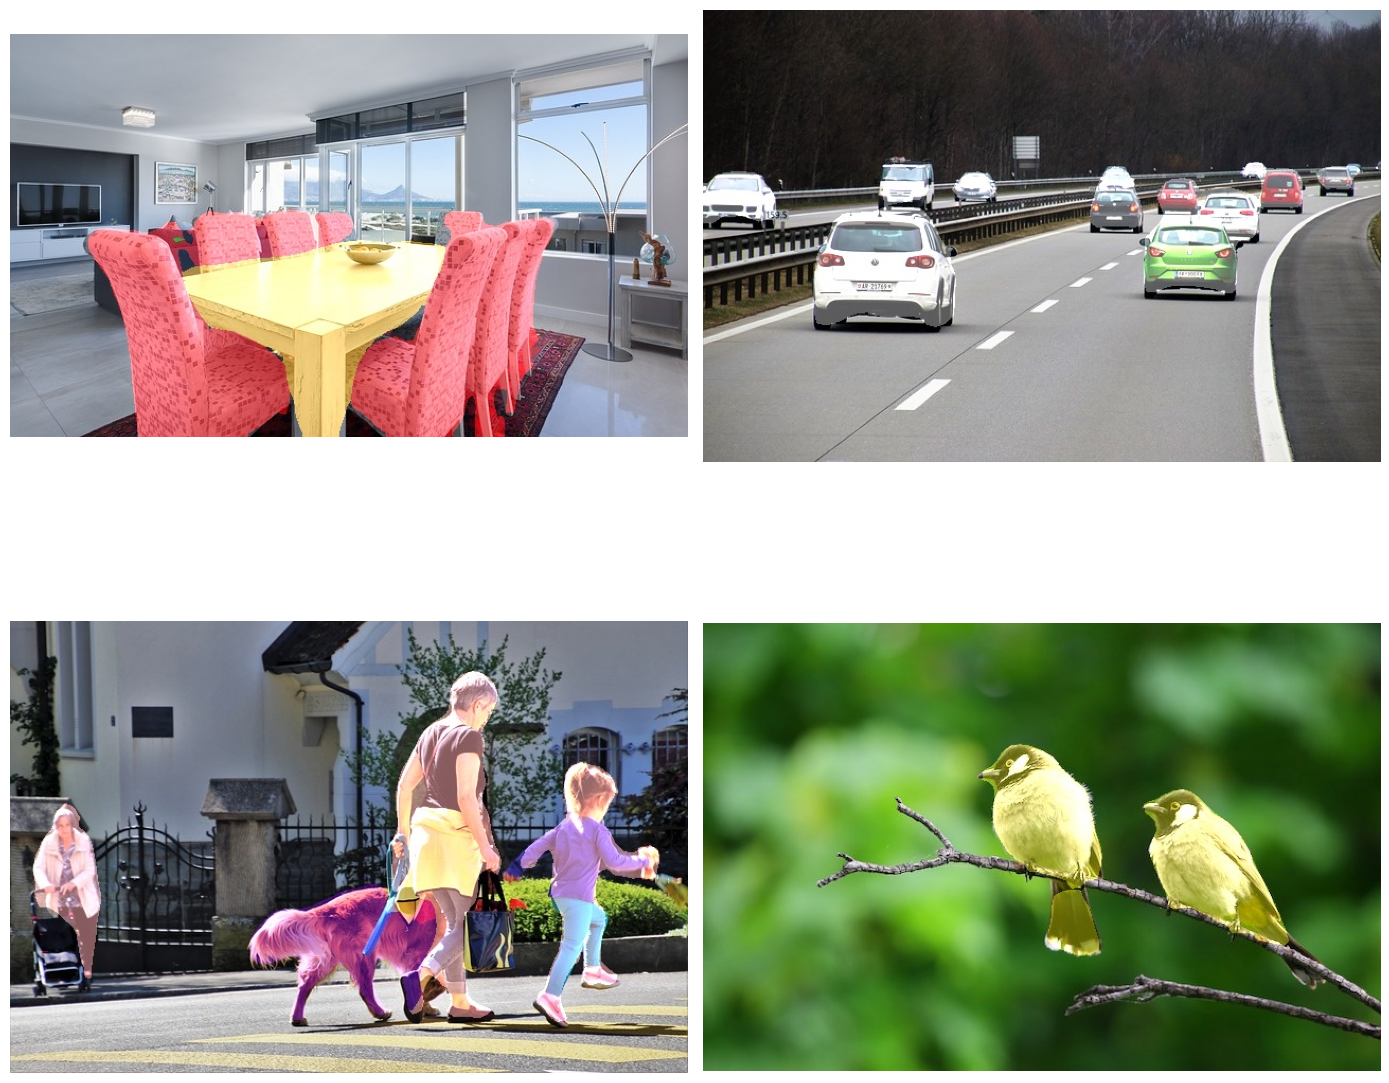

In [ ]:
visualize(OUT_DIR)